# Functional Attention Experiments

This is my implementation of [Functional Attention](https://arxiv.org/abs/2605.31559) published in ICML in 2026. I could not find all of the architecture details (number of attention blocks, choice of activation function) in the paper or its appendix. But I tried to replicate it given all the information I read in the paper.

We show below the architecture diagram

<img src=/Users/princejavier/Desktop/princejavier-github-io/supervised_learning/images/functional_attention.png width=70%>

Below is a screenshot of the details of the sinusoidal regression task:

<img src="/Users/princejavier/Desktop/princejavier-github-io/supervised_learning/images/func attention regression task.png" width=70%>


## Experiment and Results

For this experiment, we randomly generated a training set of 500 functions of $f(x) = \alpha \sin(x-\gamma)$ for $x \in [-6, 6]$, with parameters randomly sampled from uniform distributions:
* $\alpha \in [0.1, 5]$
* $\gamma \in [0, \pi]$

We trained for 500 epochs.

We first tested on a test set generated as another set of 500 functions generated from the same ranges of parameters above.

We then tested on a test set generated from a different set of ranges to test out of distribution generalization:
* $\alpha \in [5, 10]$
* $\gamma \in [0, \pi]$

## Implementation

### Functional Attention

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
device = 'cpu'

In [2]:
class FunctionalAttention(nn.Module):
    def __init__(self, 
                 d_model: int, 
                 k_basis: int, 
                 H: int, # heads
                 reg_lambda: float = 1e-4):
        super().__init__()
        self.d_model = d_model
        self.k_basis = k_basis
        self.reg_lambda = reg_lambda
        self.H = H # heads
        
        # feature projections
        self.q_proj = nn.Linear(d_model, H * d_model)
        self.k_proj = nn.Linear(d_model, H * d_model)
        self.v_proj = nn.Linear(d_model, H * d_model)
        
        # basis projections
        self.q_basis_proj = nn.Linear(H * d_model, H * k_basis)
        self.k_basis_proj = nn.Linear(H * d_model, H * k_basis)

        # output layer to make same dim as x
        self.output = nn.Linear(H * d_model, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, N, D)
        B, N, D = x.shape
        
        # linear feature projections -> (B, N, D)
        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)
        
        # compute basis functions & normalize along basis dimension K -> (B, N, K)
        phi_q = torch.softmax(self.q_basis_proj(q), dim=-1)
        phi_k = torch.softmax(self.k_basis_proj(k), dim=-1)

        # reshape to add 8 heads(B, N, D) -> (B, H, N, D_head)
        q = q.reshape((B, N, self.H, self.d_model)).permute(0, 2, 1, 3)
        k = k.reshape((B, N, self.H, self.d_model)).permute(0, 2, 1, 3)
        v = v.reshape((B, N, self.H, self.d_model)).permute(0, 2, 1, 3)
        
        # reshape to add 8 heads(B, N, K) -> (B, H, N, K_head)
        # K_head = self.k_basis//self.H
        phi_q = phi_q.reshape(B, N, self.H, self.k_basis).permute(0, 2, 1, 3)
        phi_k = phi_k.reshape(B, N, self.H, self.k_basis).permute(0, 2, 1, 3)
        
        # project feature vectors onto basis functions to get coefficients -> (B, H, K, D_head)
        A = phi_q.transpose(-2, -1) @ q       # Source coefficients
        B_coeff = phi_k.transpose(-2, -1) @ v # Target coefficients
        
        # compute regularized covariance matrix -> (B, H, K, K)
        A_AT = A @ A.transpose(-2, -1)
        reg_eye = torch.eye(self.k_basis, device=x.device) * self.reg_lambda
        cov = A_AT + reg_eye
        
        # colve for C via Least Squares: C = B_coeff @ A^T @ inv(cov) -> (B, H, K, K)

        # The literal implementation:
        # cov_inv = torch.linalg.inv(cov)
        # A_T_cov_inv = A.transpose(-2, -1) @ cov_inv # (B, H, D_head, K)
        
        # Supposedly a more efficient way to solve:
        # torch.linalg.solve(cov, A).transpose() = (cov^-1 @ A).transpose = A^T @ cov^-1
        # cov^-1 = (conv^-1)^T because cov is symmetric

        A_T_cov_inv = torch.linalg.solve(cov, A).transpose(-2, -1) # (B, H, D_head, K)
        C = B_coeff @ A_T_cov_inv              # (B, H, K, K)
        
        # transform source coefficients through functional operator C -> (B, H, K, D_head)
        c_out = C @ A
        
        # reconstruct spatial output signal Y -> (B, H, N, D_head)
        out = phi_q @ c_out

        # return to (B, N, D)
        out = out.permute(0, 2, 1, 3) # (B, H, N, D_head) -> (B, N, H, D_head)
        out = out.flatten(2) # (B, N, H, D_head) -> (B, N, D)
        out = self.output(out)
        
        return out

### Transformer Block

In [3]:
class FunctionalTransformerBlock(nn.Module):
    def __init__(self, 
                 d_model:int,
                 k_basis:int,
                 H:int,
                 ffn_hidden: int = 512,
                 reg_lambda: float = 1e-4
                 ):
        super().__init__()

        # following the architecture in the paper
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = FunctionalAttention(d_model, k_basis, H, reg_lambda)

        self.norm2 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ffn_hidden),
            nn.GELU(),
            nn.Linear(ffn_hidden, d_model)
        )

    def forward(self, x):
        x_norm = self.norm1(x)
        attn_out = self.attn(x)
        add1 = x_norm + attn_out
        add1_norm = self.norm2(add1)
        ffn_out = self.ffn(add1_norm)
        out = add1_norm + ffn_out
        return out
        

### Full Regression Model

In [4]:
class SineWaveRegressionModel(nn.Module):
    def __init__(self, 
                 k_basis:int,
                 num_blocks: int = 2,
                 d_model:int = 128,                 
                 H:int = 8,
                 inf_features:int = 2,                 
                 ffn_hidden: int = 512,
                 reg_lambda: float = 1e-4                 
                 ):
        super().__init__()

        # shared Key/Query Encoder: MLP(4, 128)
        # GELU arbitrarily chosen
        self.shared_kq_encoder = nn.Sequential(
            nn.Linear(inf_features, d_model),
            nn.GELU(),
            # nn.ReLU(),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            # nn.ReLU(),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            # nn.ReLU(),
            nn.Linear(d_model, d_model),
            nn.GELU()
            # nn.ReLU(),
        )

        self.transformer_stack = nn.ModuleList([
        FunctionalTransformerBlock(d_model, k_basis, H, ffn_hidden, reg_lambda)
        for _ in range(num_blocks)])

        # Final projection to get our 1D y-value prediction
        self.output_proj = nn.Linear(d_model, 1)

    def forward(self, x):
        x1 = self.shared_kq_encoder(x)
        for block in self.transformer_stack:
            x1 = block(x1)
        out = self.output_proj(x1)
        return out

### Generate Data

In [5]:
def generate_data(batch_size=3,
                  x_range=(-6, 6),
                  alpha_range=(.1, 5),
                  gamma_range = (0, np.pi)
                  ):

    # build the input X
    x = torch.arange(x_range[0], x_range[1], step=0.1)
    X = torch.zeros(size=(batch_size, len(x), 2))
    Y_true = torch.zeros(size=(batch_size, len(x), 1))
    Y_target = torch.zeros(size=(batch_size, len(x), 1))
    batch_mask = torch.zeros(size=(batch_size, len(x), 1))

    for b in range(batch_size):
        alpha = np.random.uniform(alpha_range[0], alpha_range[1])
        gamma = np.random.uniform(gamma_range[0], gamma_range[1])
        x = torch.arange(-6, 6, step=0.1)
        y_true = alpha * torch.sin(x - gamma)

        # mask all ys as 0s except 4 random points
        N = len(x)
        mask = torch.zeros(N)
        context_indices = torch.randperm(N)[:4]
        mask[context_indices] = 1
        y_masked = y_true * mask

        X[b, :, 0] = x
        X[b, :, 1] = y_masked
        Y_true[b, :, 0] = y_true
        Y_target[b, :, 0] = y_true * (1 - mask) # reverse mask
        batch_mask[b, :, 0] = mask

    return X, Y_true, batch_mask

In [55]:
X_train, Y_train, batch_mask_train = generate_data(
    batch_size=100,
    x_range=(-6, 6),
    alpha_range=(.1, 5),
    gamma_range = (0, np.pi)
    )

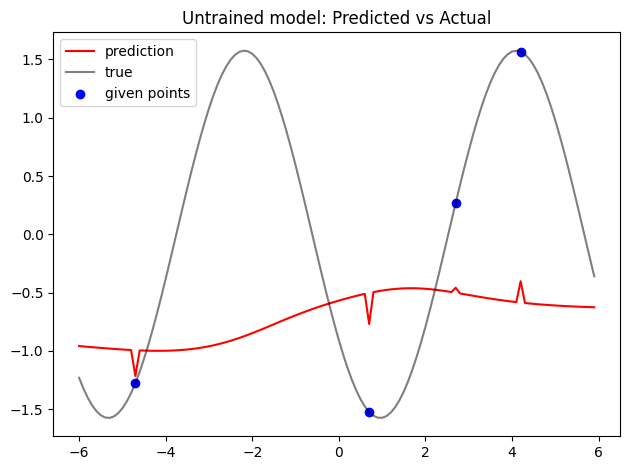

In [56]:
model = SineWaveRegressionModel(k_basis=8)
Y_pred = model(X_train)
for i in range(1):
    plt.plot(X_train[i, :, 0], Y_pred[i].detach().numpy().flatten(), color='r', label='prediction')
    plt.plot(X_train[i, :, 0], Y_train[i], color='k', alpha=0.5, label='true')
    plt.scatter(X_train[i, :, 0].flatten()[batch_mask_train[i].flatten()==1], 
                Y_train[i].flatten()[batch_mask_train[i].flatten()==1], c='b', label='given points')
    plt.title("Untrained model: Predicted vs Actual")
plt.legend()
plt.tight_layout()
plt.show()

### Train Model

In [57]:
# define dataset for helper functions like batching
from torch.utils.data import DataLoader, TensorDataset
train_dataset = TensorDataset(X_train, Y_train)
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)

In [ ]:
import torch.optim as optim

# In the paper: 50k iterations with batch size of 8
epochs = 500
model = SineWaveRegressionModel(k_basis=8, num_blocks=2)
model = model.to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()

losses = []

for epoch in range(epochs):
    loss_sum = 0
    for X_train, Y_train in train_dataloader:

        X_train = X_train.to(device)
        Y_train = Y_train.to(device)

        predictions = model(X_train)

        # # if we only compute the loss on the targets
        # # this is not great - causes spikes along given y
        # so we include targets in the MSE loss
        # target_preds = predictions.flatten()[batch_mask_train.flatten()==0]
        # target_true = Y_train.flatten()[batch_mask_train.flatten()==0]

        loss = criterion(predictions, Y_train)

        # clear gradients
        optimizer.zero_grad()

        # new gradients
        loss.backward()

        # update model weights
        optimizer.step()

        # get loss sum
        loss_sum += loss.cpu().detach().numpy()

    losses += [loss_sum / len(train_dataloader)]

    if epoch % 100 == 0:
        print(loss)

tensor(4.4888, grad_fn=<MseLossBackward0>)


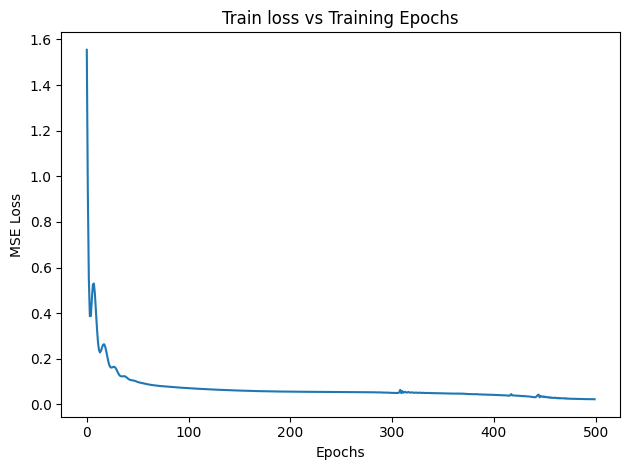

In [40]:
plt.plot(range(epochs), losses)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Train loss vs Training Epochs")
plt.tight_layout()

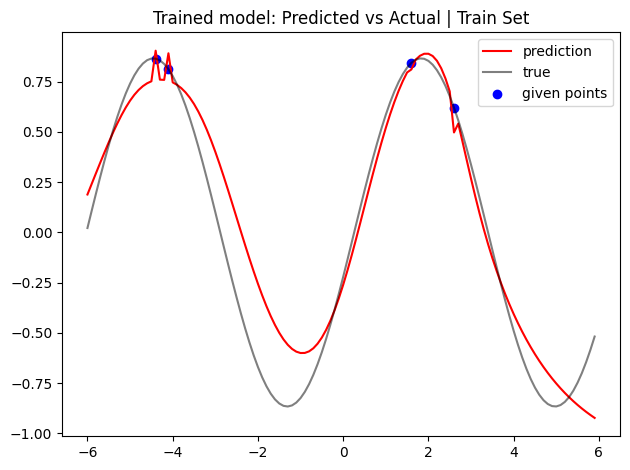

In [41]:
Y_pred = model(X_train)
for i in range(1):
    plt.plot(X_train[i, :, 0], Y_pred[i].detach().numpy().flatten(), color='r', label='prediction')
    plt.plot(X_train[i, :, 0], Y_train[i], color='k', alpha=0.5, label='true')
    plt.scatter(X_train[i, :, 0].flatten()[batch_mask_train[i].flatten()==1], 
                Y_train[i].flatten()[batch_mask_train[i].flatten()==1], c='b', label='given points')
    plt.title("Trained model: Predicted vs Actual | Train Set")
plt.legend()
plt.tight_layout()
plt.show()

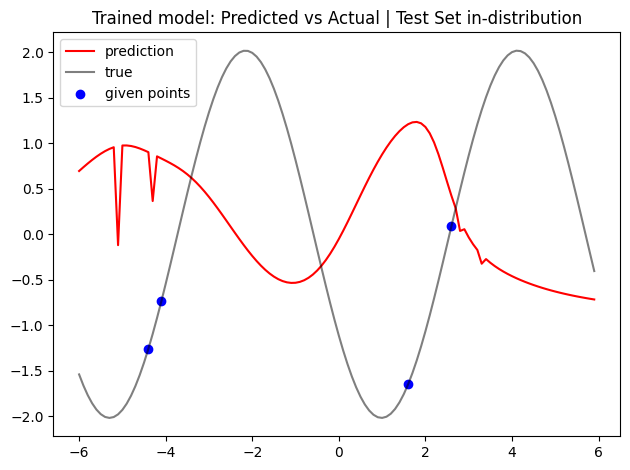

In [42]:
# in-distribution
X_test, Y_test, batch_mask_test = generate_data(batch_size=3,
                                      x_range=(-6, 6),
                                      alpha_range=(.1, 5),
                                      gamma_range = (0, np.pi)
                                      )

Y_pred = model(X_test)
for i in range(1):
    plt.plot(X_test[i, :, 0], Y_pred[i].detach().numpy().flatten(), color='r', label='prediction')
    plt.plot(X_test[i, :, 0], Y_test[i], color='k', alpha=0.5, label='true')
    plt.scatter(X_test[i, :, 0].flatten()[batch_mask_train[i].flatten()==1], 
                Y_test[i].flatten()[batch_mask_train[i].flatten()==1], c='b', label='given points')
    plt.title("Trained model: Predicted vs Actual | Test Set in-distribution")
plt.legend()
plt.tight_layout()
plt.show()

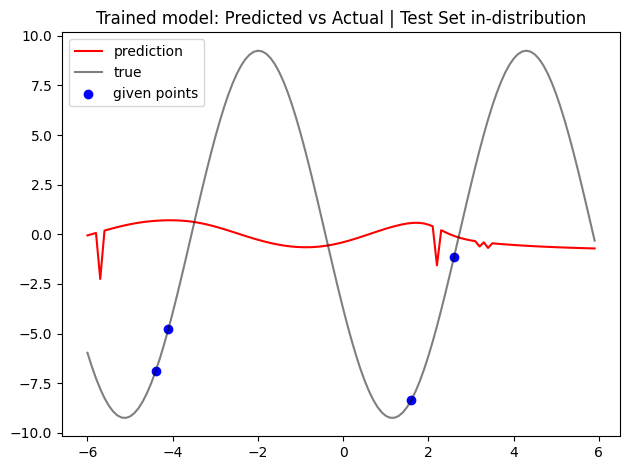

In [46]:
# out-of-distribution
X_test, Y_test, batch_mask_test = generate_data(batch_size=3,
                                      x_range=(-6, 6),
                                      alpha_range=(5, 10),
                                      gamma_range = (0, np.pi)
                                      )

Y_pred = model(X_test)
for i in range(1):
    plt.plot(X_test[i, :, 0], Y_pred[i].detach().numpy().flatten(), color='r', label='prediction')
    plt.plot(X_test[i, :, 0], Y_test[i], color='k', alpha=0.5, label='true')
    plt.scatter(X_test[i, :, 0].flatten()[batch_mask_train[i].flatten()==1], 
                Y_test[i].flatten()[batch_mask_train[i].flatten()==1], c='b', label='given points')
    plt.title("Trained model: Predicted vs Actual | Test Set in-distribution")
plt.legend()
plt.tight_layout()
plt.show()